# Part 4: Evaluation

In [4]:
import gc
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from src.baseline_features import train_logreg, evaluate_model
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

## Step 1: Load Trained Baseline Model
We load the baseline model and vectorizer trained in Part 2.

In [5]:
import joblib

model = joblib.load('../models/baseline_model.joblib')
vectorizer = joblib.load('../models/baseline_vectorizer.joblib')

print("Model and vectorizer loaded.")

Model and vectorizer loaded.


## Step 2: Evaluate on FakeNewsCorpus Test Set
We evaluate the baseline model on the held-out test set.

In [6]:
# Part 4 - Evaluate on test set
TEST_PATH = '../data/processed/news_stratified_test.csv'

test_df = pd.read_csv(
    TEST_PATH,
    usecols=['content_processed', 'type'],
    on_bad_lines='skip',
    dtype={'type': 'int8'}
)
test_df = test_df.dropna(subset=['content_processed', 'type']).copy()
test_df['type'] = test_df['type'].astype(int)

X_test = vectorizer.transform(test_df['content_processed'].fillna('').astype(str))
y_test = test_df['type'].values

del test_df
gc.collect()

results_test = evaluate_model(model, X_test, y_test, label_names=['reliable', 'fake'])
print(results_test['report'])
print(f"Macro F1: {results_test['macro_f1']:.4f}")
print("\nConfusion matrix:")
print(results_test['confusion_matrix'])

              precision    recall  f1-score   support

    reliable       0.85      0.82      0.84     41308
        fake       0.87      0.89      0.88     53414

    accuracy                           0.86     94722
   macro avg       0.86      0.86      0.86     94722
weighted avg       0.86      0.86      0.86     94722

Macro F1: 0.8565

Confusion matrix:
[[33992  7316]
 [ 6008 47406]]


## Step 3: Evaluate on LIAR Dataset
We evaluate the baseline model on the LIAR dataset without retraining. LIAR has 6 labels which we map to binary: true, mostly-true, and half-true become reliable (0), while barely-true, false, and pants-fire become fake (1).

In [12]:
# Load the full LIAR set
liar_files = [
    '../data/raw/liar/train.tsv',
    '../data/raw/liar/valid.tsv',
    '../data/raw/liar/test.tsv'
]

liar_cols = [0, 1, 2]  # id, label, statement
dfs = []

for path in liar_files:
    df_temp = pd.read_csv(
        path,
        sep='\t',
        header=None,
        usecols=liar_cols,
        names=['id', 'label', 'statement']
    )
    dfs.append(df_temp)

liar_df = pd.concat(dfs, ignore_index=True)

# Map 6 labels to binary
reliable_labels = {'true', 'mostly-true', 'half-true'}
liar_df['type'] = liar_df['label'].apply(lambda x: 0 if x in reliable_labels else 1)

print(f"LIAR set: {liar_df.shape}")
print(f"\nOriginal label distribution:\n{liar_df['label'].value_counts()}")
print(f"\nBinary label distribution:\n{liar_df['type'].value_counts()}")

LIAR set: (12791, 4)

Original label distribution:
label
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047
Name: count, dtype: int64

Binary label distribution:
type
0    7134
1    5657
Name: count, dtype: int64


## Step 4: Cross-Domain Evaluation
We apply the preprocessing pipeline to the LIAR statements and evaluate the baseline model directly.

In [13]:
# Part 4 - Preprocess LIAR statements and evaluate
from src.preprocessing import normalize_text
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

def process_text(text):
    text = normalize_text(text)
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

liar_df['content_processed'] = liar_df['statement'].apply(process_text)

X_liar = vectorizer.transform(liar_df['content_processed'].fillna('').astype(str))
y_liar = liar_df['type'].values

results_liar = evaluate_model(model, X_liar, y_liar, label_names=['reliable', 'fake'])
print(results_liar['report'])
print(f"Macro F1: {results_liar['macro_f1']:.4f}")
print("\nConfusion matrix:")
print(results_liar['confusion_matrix'])

              precision    recall  f1-score   support

    reliable       0.60      0.06      0.12      7134
        fake       0.45      0.95      0.61      5657

    accuracy                           0.45     12791
   macro avg       0.52      0.51      0.36     12791
weighted avg       0.53      0.45      0.33     12791

Macro F1: 0.3613

Confusion matrix:
[[ 462 6672]
 [ 302 5355]]


## Confusion Matrices
We visualize the confusion matrices for the baseline model on both datasets.

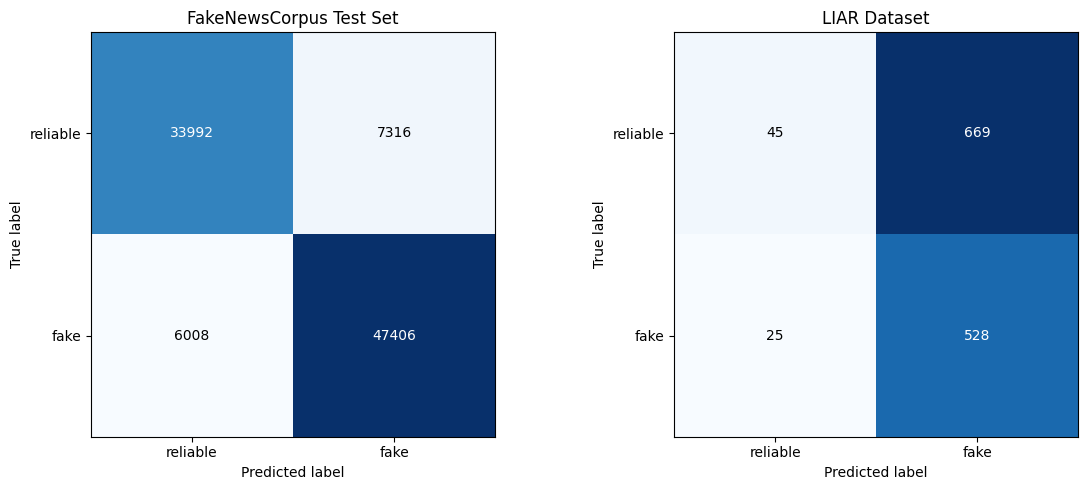

In [10]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

def plot_confusion_matrix(cm, title, ax):
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    tick_marks = [0, 1]
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(['reliable', 'fake'])
    ax.set_yticklabels(['reliable', 'fake'])
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_confusion_matrix(results_test['confusion_matrix'], 'FakeNewsCorpus Test Set', axes[0])
plot_confusion_matrix(results_liar['confusion_matrix'], 'LIAR Dataset', axes[1])

plt.tight_layout()
plt.savefig('../figures/confusion_matrices_baseline.png', dpi=200, bbox_inches='tight')
plt.show()